# Notebook 01: Radar Data Audit and Preprocessing (D2)

**Goal:** In this notebook, we perform a complete audit of the Micro-Doppler radar dataset (`D2`), check for missing values, duplicates, and outliers, map the 4 original classes into our 3 target classes (**Bird = 0, Drone = 1, Other = 2**), perform a stratified 70 / 15 / 15 train-validation-test split, extract time-domain and frequency-domain features without data leakage, remove redundant/correlated features, scale the data, and save the processed files for model training.


### Step 1: Imports, Random Seed, and Folder Setup
We start by importing standard scientific libraries (`numpy`, `pandas`, `scipy`, `sklearn`, `matplotlib`, `seaborn`). We fix `SEED = 42` so every random operation is 100% reproducible, and ensure output directories exist.


In [1]:
# Standard library and numerical imports
import os
import random
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Define folder paths
DATA_RAW = '../data/raw/d2_radar'
DATA_PROCESSED = '../data/processed'
MODELS_STORE = '../models_store'
FIGURES_DIR = '../reports/figures'
TABLES_DIR = '../reports/tables'

# Ensure directories exist
for folder in [DATA_PROCESSED, MODELS_STORE, FIGURES_DIR, TABLES_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Setup completed successfully. SEED set to 42.")


Setup completed successfully. SEED set to 42.


### Step 2: Load the Radar Dataset
Now we load the radar dataset (`astra_dataset.csv`) which contains the 2,800 radar time-series samples. Each row has 300 signal readings (100 time steps x 3 channels) plus the class label column. We verify the shape and data types.


In [2]:
# Load the dataset from CSV
csv_path = os.path.join(DATA_RAW, 'astra_dataset.csv')
df = pd.read_csv(csv_path)

# Check dataframe shape and column names
print("Loaded dataframe shape:", df.shape)
print("Data types summary:")
print(df.dtypes.value_counts())

# Inspect the first few columns and the label
print("\nFirst 5 rows of selected columns:")
print(df[['0', '1', '2', '298', '299', 'label']].head())


Loaded dataframe shape: (2800, 301)
Data types summary:
float64    300
int64        1
Name: count, dtype: int64

First 5 rows of selected columns:
          0         1         2       298       299  label
0 -0.213732  1.094772  0.213732  0.451776  1.611877      0
1  0.009050  0.926483  0.009050  1.478580  0.745822      1
2 -0.042993  0.055202  0.042993 -0.026961  0.713342      2
3  0.297952 -0.422853  0.297952  1.072778  0.033587      3
4  0.146009 -0.742591  0.146009 -0.793963  0.502358      0


### Step 3: Check for Missing Values (NaN/Inf) and Duplicate Rows
Before doing any processing, we check whether there are any missing values, infinite values, or duplicate signal samples in the dataset.


In [3]:
# Check for missing values (NaN)
nan_count = df.isna().sum().sum()
print("Total NaN values in dataset:", nan_count)

# Check for infinite values
feature_cols = [str(i) for i in range(300)]
inf_count = np.isinf(df[feature_cols].values).sum()
print("Total Inf values in dataset:", inf_count)

# Check for exact duplicate rows in the feature space
duplicate_count = df.duplicated(subset=feature_cols).sum()
print("Exact duplicate signal samples found:", duplicate_count)


Total NaN values in dataset: 0
Total Inf values in dataset: 0
Exact duplicate signal samples found: 0


### Step 4: Physical Interpretation of the 3 Channels
From the Micro-Doppler Aerial Classification dataset documentation:
- **Channel 0 (In-phase component / Doppler frequency):** Captures frequency shift caused by object motion and micro-motions (e.g. wing flapping or rotor blade spin).
- **Channel 1 (Quadrature component / Amplitude):** Represents the return signal amplitude and radar cross-section (RCS) modulation over time.
- **Channel 2 (Signal Magnitude / Envelope):** Represents the instantaneous envelope magnitude $\sqrt{I^2 + Q^2}$, tracking the overall energy envelope of the airborne target.

Each sample consists of $T = 100$ continuous time steps across these 3 channels, yielding a $100 \times 3$ time-series matrix per airborne target.


### Step 5: Summary Statistics per Channel, per Class
We reshape the 300 flattened columns into $(N, 100, 3)$ and compute summary statistics (min, max, mean, std) for each channel across each of the 4 original classes.


In [4]:
# Reshape the feature matrix into (samples, time_steps, channels)
X_raw = df[feature_cols].values.reshape(-1, 100, 3)
y_raw = df['label'].values

print("Reshaped 3D array shape:", X_raw.shape)

# Compute per-channel statistics for each class
class_names_4 = {0: "Bird", 1: "Drone", 2: "Aircraft", 3: "Stealth UAV"}
stats_list = []

for c_id, c_name in class_names_4.items():
    idx = (y_raw == c_id)
    X_c = X_raw[idx]
    for ch in range(3):
        vals = X_c[:, :, ch]
        stats_list.append({
            'Class': c_name,
            'Channel': f'Ch {ch}',
            'Mean': np.mean(vals),
            'Std': np.std(vals),
            'Min': np.min(vals),
            'Max': np.max(vals)
        })

stats_df = pd.DataFrame(stats_list)
print("Summary statistics per channel and per class:")
display(stats_df)


Reshaped 3D array shape: (2800, 100, 3)
Summary statistics per channel and per class:


,Class,Channel,Mean,Std,Min,Max
0,Bird,Ch 0,0.044492,0.923282,-3.301102,3.355367
1,Bird,Ch 1,0.002021,0.474135,-2.794074,2.754007
2,Bird,Ch 2,0.761706,0.523674,0.000036,3.355367
3,Drone,Ch 0,0.016360,0.725467,-1.510452,1.543225
4,Drone,Ch 1,0.006153,0.645498,-1.756504,1.595683
5,Drone,Ch 2,0.641303,0.339559,0.000005,1.543225
6,Aircraft,Ch 0,0.350376,0.210305,-0.171623,0.885078
7,Aircraft,Ch 1,0.007004,0.036527,-0.216194,0.227678
8,Aircraft,Ch 2,0.352334,0.207010,0.000005,0.885078
9,Stealth UAV,Ch 0,0.002400,0.522503,-2.147450,2.180212


### Step 6: Plot Sample Radar Signals for Each Class
To visually inspect the micro-Doppler signatures, we plot 5 random time-series signals for each class across all 3 channels.


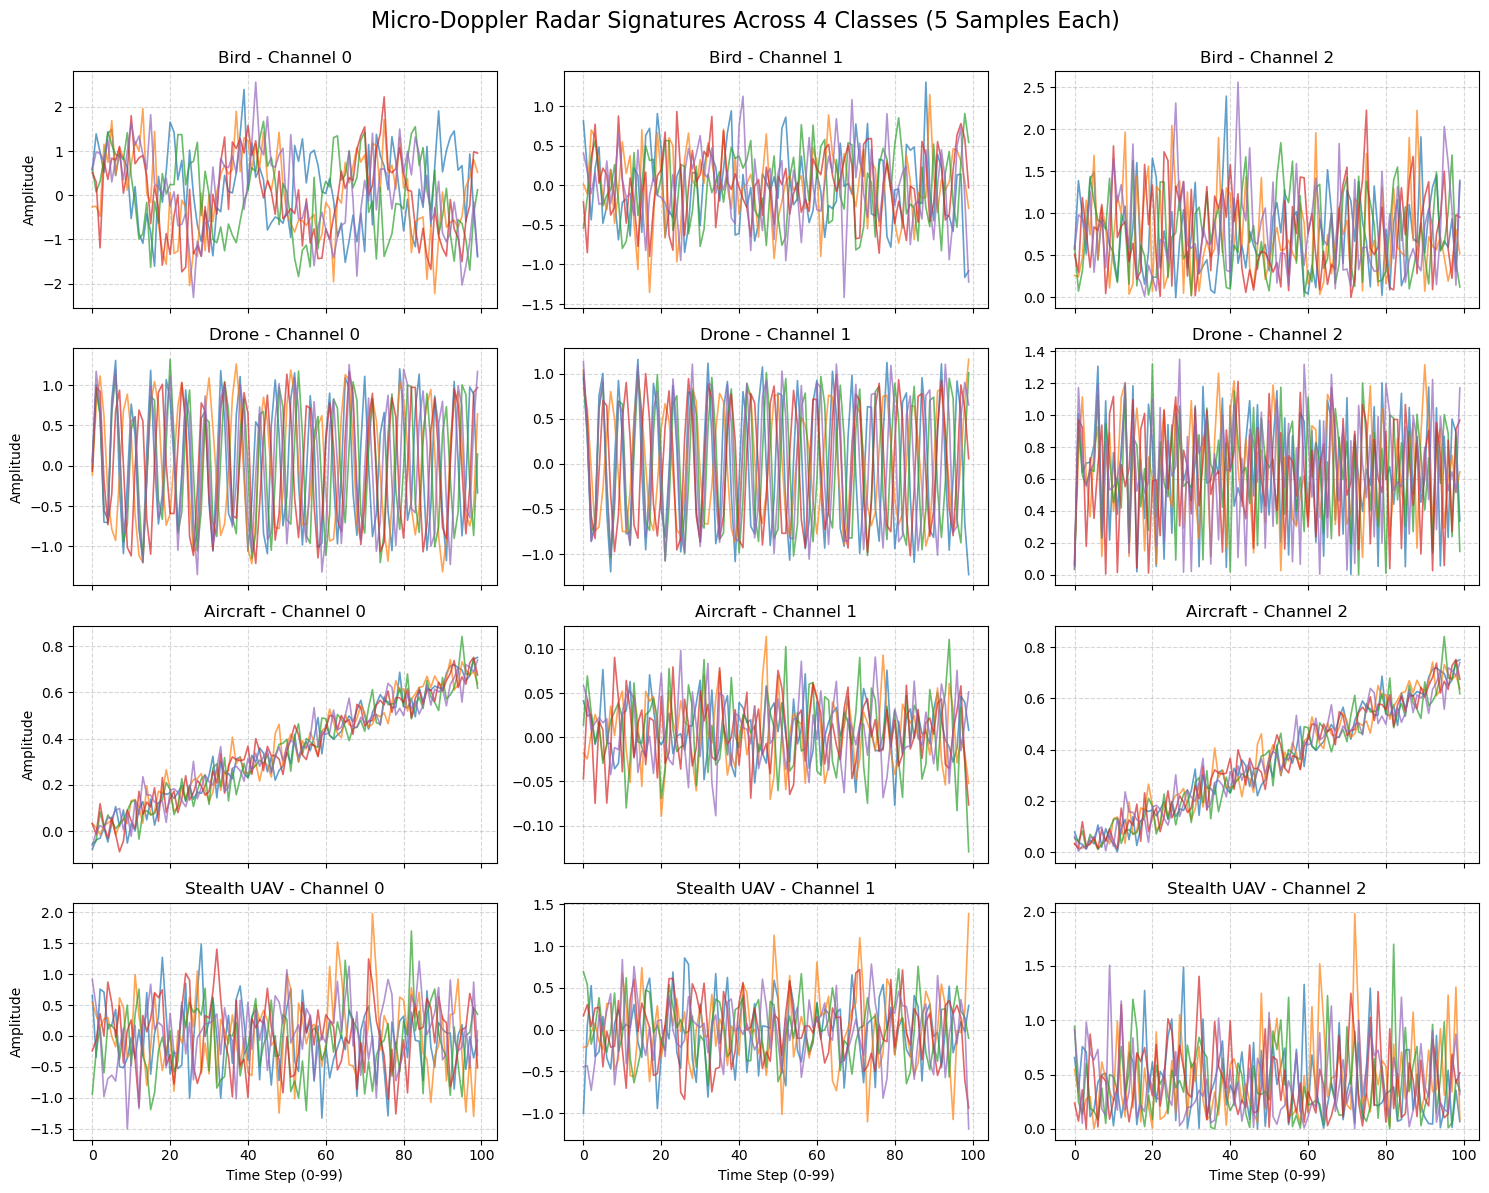

Figure saved to: ../reports/figures\radar_sample_signals.png


In [5]:
# Plot sample signals for each class
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True)

for row_idx, (c_id, c_name) in enumerate(class_names_4.items()):
    idx_class = np.where(y_raw == c_id)[0]
    # Pick 5 random sample indices
    sample_indices = np.random.choice(idx_class, size=5, replace=False)
    
    for ch in range(3):
        ax = axes[row_idx, ch]
        for s_idx in sample_indices:
            ax.plot(X_raw[s_idx, :, ch], alpha=0.7, linewidth=1.2)
        ax.set_title(f"{c_name} - Channel {ch}")
        ax.grid(True, linestyle="--", alpha=0.5)
        if ch == 0:
            ax.set_ylabel("Amplitude")
        if row_idx == 3:
            ax.set_xlabel("Time Step (0-99)")

plt.suptitle("Micro-Doppler Radar Signatures Across 4 Classes (5 Samples Each)", fontsize=16, y=0.99)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'radar_sample_signals.png')
plt.savefig(fig_path, dpi=300)
plt.show()
print("Figure saved to:", fig_path)


### Step 7: Plot Class-Wise Mean and Standard Deviation Bands
Now we compute the class-wise mean and $\pm 1$ standard deviation envelopes across the 100 time steps. This highlights the average temporal behavior and signal variability of each aerial object.


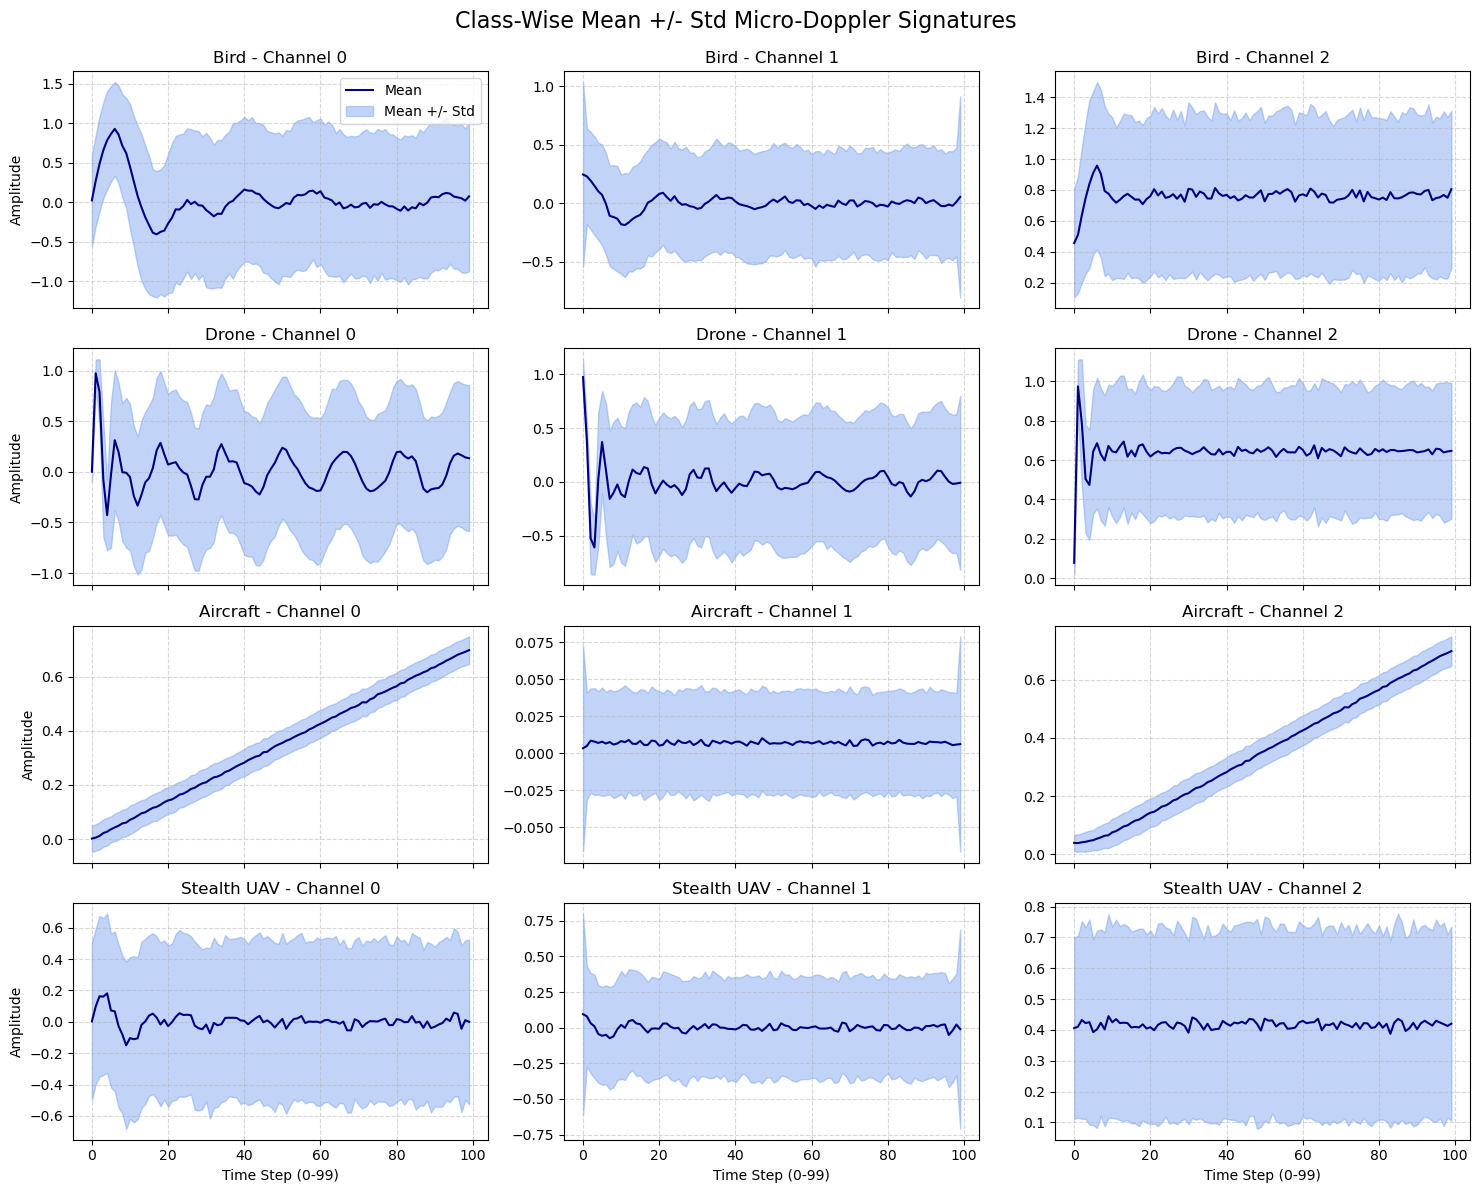

Figure saved to: ../reports/figures\radar_class_mean_std.png


In [6]:
# Plot mean +/- std bands per class for each channel
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True)
time_steps = np.arange(100)

for row_idx, (c_id, c_name) in enumerate(class_names_4.items()):
    X_c = X_raw[y_raw == c_id]
    
    for ch in range(3):
        ax = axes[row_idx, ch]
        mean_sig = np.mean(X_c[:, :, ch], axis=0)
        std_sig = np.std(X_c[:, :, ch], axis=0)
        
        ax.plot(time_steps, mean_sig, color='navy', label='Mean')
        ax.fill_between(time_steps, mean_sig - std_sig, mean_sig + std_sig, color='cornflowerblue', alpha=0.4, label='Mean +/- Std')
        ax.set_title(f"{c_name} - Channel {ch}")
        ax.grid(True, linestyle="--", alpha=0.5)
        if ch == 0:
            ax.set_ylabel("Amplitude")
        if row_idx == 3:
            ax.set_xlabel("Time Step (0-99)")
        if row_idx == 0 and ch == 0:
            ax.legend(loc='upper right')

plt.suptitle("Class-Wise Mean +/- Std Micro-Doppler Signatures", fontsize=16, y=0.99)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'radar_class_mean_std.png')
plt.savefig(fig_path, dpi=300)
plt.show()
print("Figure saved to:", fig_path)


### Step 8: Plot Original 4-Class Distribution
Next, we plot the distribution of samples across the original 4 classes to confirm dataset balance before merging.


C:\Users\athar\AppData\Local\Temp\ipykernel_27376\527118143.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_4.index, y=counts_4.values, palette='Blues_r')


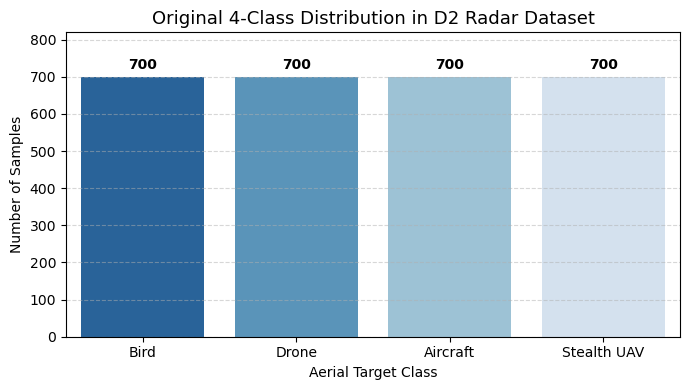

Original 4-class counts:
Bird           700
Drone          700
Aircraft       700
Stealth UAV    700
Name: count, dtype: int64


In [7]:
# Count samples per original class
counts_4 = pd.Series(y_raw).map(class_names_4).value_counts()

plt.figure(figsize=(7, 4))
sns.barplot(x=counts_4.index, y=counts_4.values, palette='Blues_r')
plt.title("Original 4-Class Distribution in D2 Radar Dataset", fontsize=13)
plt.xlabel("Aerial Target Class")
plt.ylabel("Number of Samples")
for i, v in enumerate(counts_4.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.ylim(0, max(counts_4.values) + 120)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, 'radar_class_distribution_4class.png')
plt.savefig(fig_path, dpi=300)
plt.show()
print("Original 4-class counts:")
print(counts_4)


### Step 9: Map Labels to 3 Classes (Bird = 0, Drone = 1, Other = 2)
According to the operational mission requirements:
- **Bird = 0** (harmless biological clutter)
- **Drone = 1** (critical priority threat)
- **Other = 2** (Aircraft and Stealth UAV merged)

We merge Aircraft and Stealth UAV into `Other (2)` and plot the new 3-class distribution.


C:\Users\athar\AppData\Local\Temp\ipykernel_27376\521597010.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_3.index, y=counts_3.values, palette=colors)


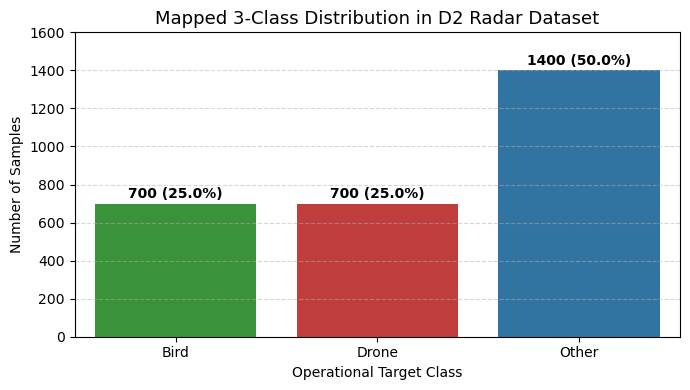

New 3-class counts and percentages:
  Bird: 700 samples (25.00%)
  Drone: 700 samples (25.00%)
  Other: 1400 samples (50.00%)


In [8]:
# Map original 4 classes to 3 classes
# 0 -> 0 (Bird), 1 -> 1 (Drone), 2 -> 2 (Other), 3 -> 2 (Other)
label_map = {0: 0, 1: 1, 2: 2, 3: 2}
y_3class = np.array([label_map[y] for y in y_raw])

class_names_3 = {0: "Bird", 1: "Drone", 2: "Other"}
counts_3 = pd.Series(y_3class).map(class_names_3).value_counts().reindex(["Bird", "Drone", "Other"])

plt.figure(figsize=(7, 4))
colors = ['#2ca02c', '#d62728', '#1f77b4'] # Green for Bird, Red for Drone, Blue for Other
sns.barplot(x=counts_3.index, y=counts_3.values, palette=colors)
plt.title("Mapped 3-Class Distribution in D2 Radar Dataset", fontsize=13)
plt.xlabel("Operational Target Class")
plt.ylabel("Number of Samples")
for i, v in enumerate(counts_3.values):
    pct = (v / len(y_3class)) * 100
    plt.text(i, v + 30, f"{v} ({pct:.1f}%)", ha='center', fontweight='bold')
plt.ylim(0, max(counts_3.values) + 200)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, 'radar_class_distribution_3class.png')
plt.savefig(fig_path, dpi=300)
plt.show()

print("New 3-class counts and percentages:")
for c_name, count in counts_3.items():
    print(f"  {c_name}: {count} samples ({count/len(y_3class)*100:.2f}%)")


### Step 10: Stratified 70 / 15 / 15 Split (Train / Val / Test)
We split the 2,800 samples into **70% Train (1,960)**, **15% Validation (420)**, and **15% Test (420)** using `StratifiedShuffleSplit` with `random_state = 42`.
This ensures identical class proportions across all three splits.


In [9]:
# First split: 70% train vs 30% temp (which will be split into 15% val and 15% test)
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(X_raw, y_3class))

# Second split: split the 30% temp into 50/50 (15% val, 15% test)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_sub_idx, test_sub_idx = next(sss2.split(X_raw[temp_idx], y_3class[temp_idx]))

val_idx = temp_idx[val_sub_idx]
test_idx = temp_idx[test_sub_idx]

# Verify sizes and no overlap
print("Split sizes:")
print(f"  Train: {len(train_idx)} samples ({len(train_idx)/len(y_3class)*100:.1f}%)")
print(f"  Validation: {len(val_idx)} samples ({len(val_idx)/len(y_3class)*100:.1f}%)")
print(f"  Test: {len(test_idx)} samples ({len(test_idx)/len(y_3class)*100:.1f}%)")

# Confirm zero leakage between split index sets
assert len(set(train_idx).intersection(set(val_idx))) == 0, "Leakage between train and val!"
assert len(set(train_idx).intersection(set(test_idx))) == 0, "Leakage between train and test!"
assert len(set(val_idx).intersection(set(test_idx))) == 0, "Leakage between val and test!"
print("Assertion passed: Zero index overlap across splits.")

# Print class counts per split
for split_name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    counts = pd.Series(y_3class[idx]).value_counts().sort_index()
    print(f"{split_name} class counts: Bird={counts[0]}, Drone={counts[1]}, Other={counts[2]}")


Split sizes:
  Train: 1960 samples (70.0%)
  Validation: 420 samples (15.0%)
  Test: 420 samples (15.0%)
Assertion passed: Zero index overlap across splits.
Train class counts: Bird=490, Drone=490, Other=980
Val class counts: Bird=105, Drone=105, Other=210
Test class counts: Bird=105, Drone=105, Other=210


### Step 11: Save Split Indices to Disk
We freeze and save the split indices to disk (`models_store/radar_split_indices.joblib`).
As specified in our execution plan, the **test indices are never touched or evaluated** until the final evaluation in Phase 7.


In [10]:
# Save split indices dictionary
split_indices = {
    'train_idx': train_idx,
    'val_idx': val_idx,
    'test_idx': test_idx,
    'seed': SEED
}
split_path = os.path.join(MODELS_STORE, 'radar_split_indices.joblib')
joblib.dump(split_indices, split_path)
print("Saved split indices to:", split_path)


Saved split indices to: ../models_store\radar_split_indices.joblib


### Step 12: Handle Outliers (Train-Only Percentile Clipping)
To prevent extreme noise spikes from distorting feature calculations without leaking future data, we compute the 0.5th and 99.5th percentiles on the **training set only**, and clip all splits using these training bounds.


In [11]:
# Compute 0.5th and 99.5th percentiles for each channel using train set only
lower_bounds = np.percentile(X_raw[train_idx], 0.5, axis=(0, 1))
upper_bounds = np.percentile(X_raw[train_idx], 99.5, axis=(0, 1))

print("Train-derived clipping bounds:")
for ch in range(3):
    print(f"  Channel {ch}: lower = {lower_bounds[ch]:.4f}, upper = {upper_bounds[ch]:.4f}")

# Clip all splits using train-derived bounds
X_clipped = np.copy(X_raw)
for ch in range(3):
    X_clipped[:, :, ch] = np.clip(X_clipped[:, :, ch], lower_bounds[ch], upper_bounds[ch])

print("Outlier clipping completed without data leakage.")


Train-derived clipping bounds:
  Channel 0: lower = -1.7720, upper = 1.8178
  Channel 1: lower = -1.0820, upper = 1.0947
  Channel 2: lower = 0.0045, upper = 1.9958
Outlier clipping completed without data leakage.


### Step 13: Time-Domain Feature Extraction
For tabular models (Random Forest, SVM, XGBoost), we extract descriptive statistical features from each of the 3 channels:
- Mean, standard deviation, min, max, range, median, IQR
- Skewness, kurtosis, Root Mean Square (RMS)
- Zero-crossing rate, mean absolute successive difference, peak count


In [12]:
# Function to extract time-domain features for a 1D signal
def extract_time_features(signal, prefix):
    feats = {}
    feats[f'{prefix}_mean'] = float(np.mean(signal))
    feats[f'{prefix}_std'] = float(np.std(signal))
    feats[f'{prefix}_min'] = float(np.min(signal))
    feats[f'{prefix}_max'] = float(np.max(signal))
    feats[f'{prefix}_range'] = float(np.ptp(signal))
    feats[f'{prefix}_median'] = float(np.median(signal))
    feats[f'{prefix}_iqr'] = float(stats.iqr(signal))
    feats[f'{prefix}_skew'] = float(stats.skew(signal))
    feats[f'{prefix}_kurtosis'] = float(stats.kurtosis(signal))
    feats[f'{prefix}_rms'] = float(np.sqrt(np.mean(signal**2)))
    
    # Zero-crossing rate (around signal mean)
    zero_crossings = np.where(np.diff(np.sign(signal - np.mean(signal))))[0]
    feats[f'{prefix}_zcr'] = float(len(zero_crossings) / len(signal))
    
    # Mean absolute difference between consecutive steps
    feats[f'{prefix}_mean_diff'] = float(np.mean(np.abs(np.diff(signal))))
    
    # Peak count (local maxima above mean + 0.5 * std)
    threshold = np.mean(signal) + 0.5 * np.std(signal)
    peaks = (signal[1:-1] > signal[:-2]) & (signal[1:-1] > signal[2:]) & (signal[1:-1] > threshold)
    feats[f'{prefix}_peak_count'] = float(np.sum(peaks))
    
    return feats

# Extract time-domain features for all samples
time_feats_list = []
for i in range(len(X_clipped)):
    sample_dict = {}
    for ch in range(3):
        ch_dict = extract_time_features(X_clipped[i, :, ch], prefix=f'ch{ch}')
        sample_dict.update(ch_dict)
    time_feats_list.append(sample_dict)

df_time = pd.DataFrame(time_feats_list)
print("Extracted time-domain features shape:", df_time.shape)
print("Sample of first 5 time features:")
display(df_time.iloc[:3, :6])


Extracted time-domain features shape: (2800, 39)
Sample of first 5 time features:


,ch0_mean,ch0_std,ch0_min,ch0_max,ch0_range,ch0_median
0,0.074257,0.896778,-1.771951,1.817827,3.589778,0.061833
1,0.008108,0.721849,-1.287992,1.087252,2.375244,0.026736
2,0.348728,0.216381,-0.042993,0.740302,0.783296,0.337609


### Step 14: Frequency-Domain Feature Extraction (FFT and Spectral Properties)
Next, we compute spectral features using Fast Fourier Transform (FFT):
- Dominant frequency and dominant peak power
- Spectral centroid (center of mass of the spectrum)
- Spectral bandwidth (spread of frequencies around centroid)
- Spectral entropy (measure of spectral complexity / randomness)
- Sub-band energies (low: 0-15%, mid: 15-40%, high: 40-100% of spectrum)
- Spectral flatness (geometric mean / arithmetic mean of power spectrum)


In [13]:
# Function to extract frequency-domain features for a 1D signal
def extract_freq_features(signal, prefix):
    feats = {}
    N = len(signal)
    fft_vals = np.fft.rfft(signal)
    fft_mag = np.abs(fft_vals)
    psd = fft_mag ** 2
    psd_sum = np.sum(psd) + 1e-12
    norm_psd = psd / psd_sum
    freqs = np.fft.rfftfreq(N, d=1.0) # normalized frequency [0, 0.5]
    
    # Dominant frequency
    dom_idx = np.argmax(fft_mag[1:]) + 1 if len(fft_mag) > 1 else 0
    feats[f'{prefix}_dom_freq'] = float(freqs[dom_idx])
    feats[f'{prefix}_dom_power'] = float(fft_mag[dom_idx])
    
    # Spectral centroid
    centroid = np.sum(freqs * norm_psd)
    feats[f'{prefix}_spectral_centroid'] = float(centroid)
    
    # Spectral bandwidth (spread around centroid)
    bandwidth = np.sqrt(np.sum(((freqs - centroid)**2) * norm_psd))
    feats[f'{prefix}_spectral_bandwidth'] = float(bandwidth)
    
    # Spectral entropy
    entropy = -np.sum(norm_psd * np.log2(norm_psd + 1e-12))
    feats[f'{prefix}_spectral_entropy'] = float(entropy)
    
    # Band energy ratios (low, mid, high)
    n_bins = len(freqs)
    b_low = int(n_bins * 0.15)
    b_mid = int(n_bins * 0.40)
    feats[f'{prefix}_energy_low'] = float(np.sum(psd[:b_low]) / psd_sum)
    feats[f'{prefix}_energy_mid'] = float(np.sum(psd[b_low:b_mid]) / psd_sum)
    feats[f'{prefix}_energy_high'] = float(np.sum(psd[b_mid:]) / psd_sum)
    
    # Spectral flatness
    geom_mean = np.exp(np.mean(np.log(psd + 1e-12)))
    arith_mean = np.mean(psd) + 1e-12
    feats[f'{prefix}_spectral_flatness'] = float(geom_mean / arith_mean)
    
    return feats

# Extract frequency features for all samples
freq_feats_list = []
for i in range(len(X_clipped)):
    sample_dict = {}
    for ch in range(3):
        ch_dict = extract_freq_features(X_clipped[i, :, ch], prefix=f'ch{ch}')
        sample_dict.update(ch_dict)
    freq_feats_list.append(sample_dict)

df_freq = pd.DataFrame(freq_feats_list)
print("Extracted frequency-domain features shape:", df_freq.shape)
print("Sample of first 5 frequency features:")
display(df_freq.iloc[:3, :6])


Extracted frequency-domain features shape: (2800, 27)
Sample of first 5 frequency features:


,ch0_dom_freq,ch0_dom_power,ch0_spectral_centroid,ch0_spectral_bandwidth,ch0_spectral_entropy,ch0_energy_low
0,0.03,44.551534,0.133641,0.157558,3.607181,0.626354
1,0.24,40.065929,0.238562,0.044143,2.146928,0.027971
2,0.01,11.625337,0.008057,0.041304,1.070997,0.973478


### Step 15: Add Cross-Channel Features and Combine Feature Table
We also compute cross-channel Pearson correlation coefficients between each pair of channels:
- Correlation between Channel 0 and Channel 1
- Correlation between Channel 0 and Channel 2
- Correlation between Channel 1 and Channel 2

Then we merge time-domain, frequency-domain, and cross-channel features into one complete tabular dataset.


In [14]:
# Extract cross-channel correlation features
cross_feats_list = []
for i in range(len(X_clipped)):
    ch0 = X_clipped[i, :, 0]
    ch1 = X_clipped[i, :, 1]
    ch2 = X_clipped[i, :, 2]
    
    # Pearson correlation with safety against zero-std signals
    r01, _ = stats.pearsonr(ch0, ch1) if (np.std(ch0)>1e-8 and np.std(ch1)>1e-8) else (0.0, 0.0)
    r02, _ = stats.pearsonr(ch0, ch2) if (np.std(ch0)>1e-8 and np.std(ch2)>1e-8) else (0.0, 0.0)
    r12, _ = stats.pearsonr(ch1, ch2) if (np.std(ch1)>1e-8 and np.std(ch2)>1e-8) else (0.0, 0.0)
    
    cross_feats_list.append({
        'corr_ch0_ch1': float(0.0 if np.isnan(r01) else r01),
        'corr_ch0_ch2': float(0.0 if np.isnan(r02) else r02),
        'corr_ch1_ch2': float(0.0 if np.isnan(r12) else r12)
    })

df_cross = pd.DataFrame(cross_feats_list)

# Combine all engineered features into one table
df_features = pd.concat([df_time, df_freq, df_cross], axis=1)
print("Combined features table shape:", df_features.shape)
print("Total engineered feature count:", df_features.shape[1])


Combined features table shape: (2800, 69)
Total engineered feature count: 69


### Step 16: Remove Near-Constant and Redundant Features (Train-Only Decision)
Features with near-zero variance hold no discriminatory power, and features with absolute Pearson correlation $|r| > 0.95$ introduce redundancy.
Crucially, **we calculate variance and correlations solely on the training split** to strictly prevent leakage.


Low variance columns to drop: []
Highly correlated (|r| > 0.95) columns to drop (25 features): ['ch0_range', 'ch0_median', 'ch0_rms', 'ch1_min', 'ch1_max', 'ch1_range', 'ch1_iqr', 'ch1_rms', 'ch1_mean_diff', 'ch2_mean', 'ch2_max', 'ch2_range', 'ch2_median', 'ch2_skew', 'ch2_rms', 'ch2_zcr', 'ch2_mean_diff', 'ch0_spectral_centroid', 'ch0_spectral_flatness', 'ch1_dom_power', 'ch1_energy_high', 'ch2_spectral_bandwidth', 'ch2_energy_high', 'ch2_spectral_flatness', 'corr_ch0_ch2']

Features retained: 44 out of 69


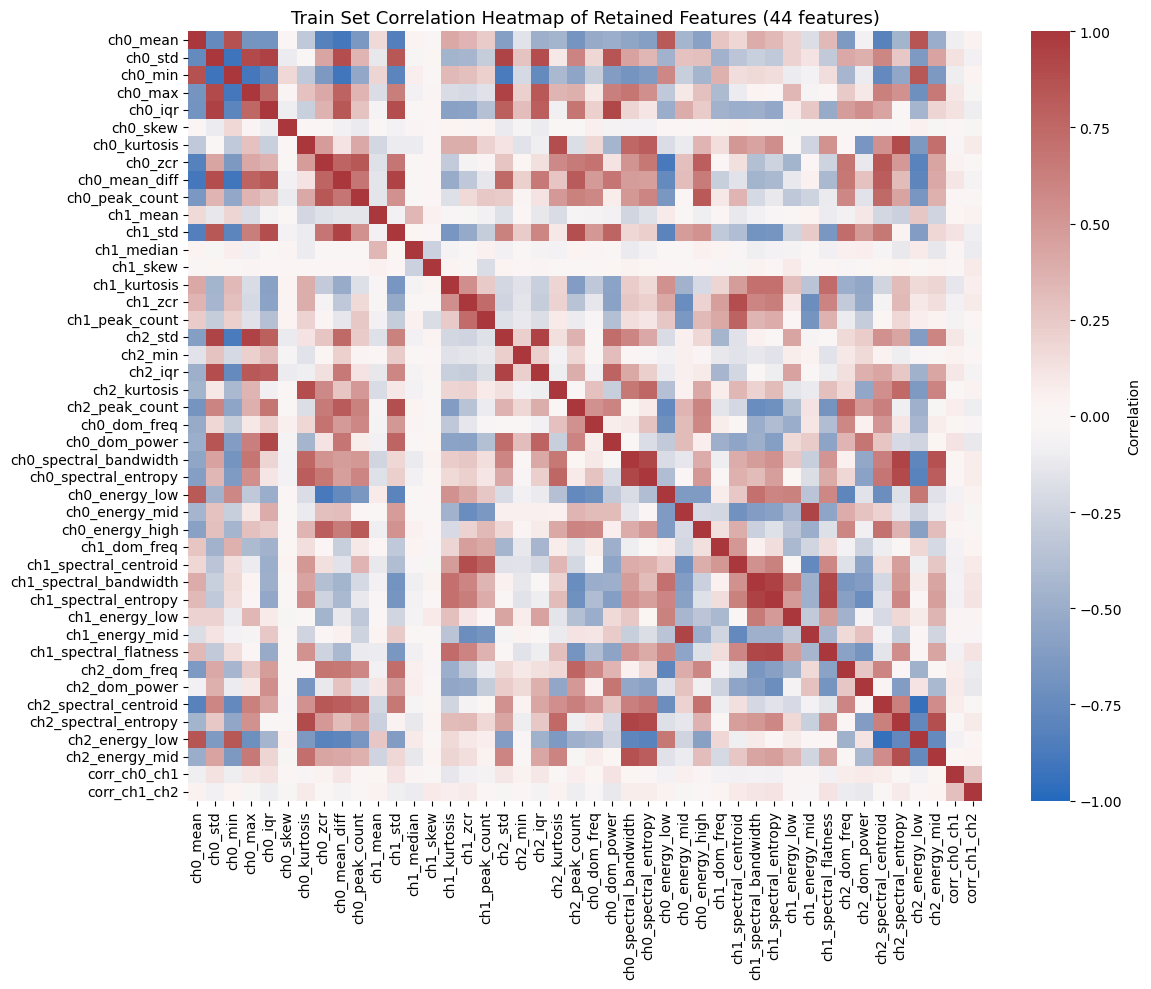

Retained features list saved.


In [15]:
# Split the features dataframe using our saved split indices
X_train_df = df_features.iloc[train_idx].copy()
X_val_df = df_features.iloc[val_idx].copy()
X_test_df = df_features.iloc[test_idx].copy()

# 1. Variance check on training features
variances = X_train_df.var()
low_var_cols = variances[variances < 1e-5].index.tolist()
print("Low variance columns to drop:", low_var_cols)

# 2. Correlation filter on training features (|r| > 0.95)
corr_matrix = X_train_df.drop(columns=low_var_cols).corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]
print(f"Highly correlated (|r| > 0.95) columns to drop ({len(high_corr_cols)} features):", high_corr_cols)

# Drop redundant features based on train-only analysis
features_to_drop = list(set(low_var_cols + high_corr_cols))
selected_features = [col for col in df_features.columns if col not in features_to_drop]

print(f"\nFeatures retained: {len(selected_features)} out of {df_features.shape[1]}")

# Plot correlation heatmap of the retained features on train set
plt.figure(figsize=(12, 10))
sns.heatmap(X_train_df[selected_features].corr(), cmap='vlag', vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
plt.title(f"Train Set Correlation Heatmap of Retained Features ({len(selected_features)} features)", fontsize=13)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'radar_correlation_heatmap.png')
plt.savefig(fig_path, dpi=300)
plt.show()
print("Retained features list saved.")


### Step 17: Feature Scaling with StandardScaler (Fit on Train Only)
We initialize `StandardScaler`, **fit it exclusively on `X_train`**, and use the fitted scaler to transform `X_val` and `X_test`.
This guarantees zero test-set information leaks into model inputs.


In [16]:
# Fit scaler ONLY on train set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df[selected_features])

# Transform val and test using train-fitted scaler
X_val_scaled = scaler.transform(X_val_df[selected_features])
X_test_scaled = scaler.transform(X_test_df[selected_features])

# Extract labels for each split
y_train = y_3class[train_idx]
y_val = y_3class[val_idx]
y_test = y_3class[test_idx]

print("Scaled arrays shapes:")
print("  X_train_scaled:", X_train_scaled.shape, "y_train:", y_train.shape)
print("  X_val_scaled:  ", X_val_scaled.shape, "y_val:  ", y_val.shape)
print("  X_test_scaled: ", X_test_scaled.shape, "y_test: ", y_test.shape)

# Verify train mean is ~0 and std is ~1
print(f"Train mean (first 5 features): {X_train_scaled[:, :5].mean(axis=0).round(4)}")
print(f"Train std  (first 5 features): {X_train_scaled[:, :5].std(axis=0).round(4)}")


Scaled arrays shapes:
  X_train_scaled: (1960, 44) y_train: (1960,)
  X_val_scaled:   (420, 44) y_val:   (420,)
  X_test_scaled:  (420, 44) y_test:  (420,)
Train mean (first 5 features): [0. 0. 0. 0. 0.]
Train std  (first 5 features): [1. 1. 1. 1. 1.]


### Step 18: Save Processed Arrays, Scaler, and Metadata to Disk
We persist all processed arrays, the fitted scaler, and the final list of feature names to `data/processed/` and `models_store/`.
Notebook 02 will load these clean arrays directly.


In [17]:
# Save processed feature arrays
np.save(os.path.join(DATA_PROCESSED, 'radar_X_train.npy'), X_train_scaled)
np.save(os.path.join(DATA_PROCESSED, 'radar_y_train.npy'), y_train)
np.save(os.path.join(DATA_PROCESSED, 'radar_X_val.npy'), X_val_scaled)
np.save(os.path.join(DATA_PROCESSED, 'radar_y_val.npy'), y_val)
np.save(os.path.join(DATA_PROCESSED, 'radar_X_test.npy'), X_test_scaled)
np.save(os.path.join(DATA_PROCESSED, 'radar_y_test.npy'), y_test)

# Save scaler and selected feature names
joblib.dump(scaler, os.path.join(MODELS_STORE, 'radar_scaler.joblib'))
joblib.dump(selected_features, os.path.join(MODELS_STORE, 'radar_selected_features.joblib'))

print("All processed radar datasets and scaler artifacts saved successfully.")


All processed radar datasets and scaler artifacts saved successfully.


### Summary and What We Learned
In this notebook, we completed the full radar audit and preprocessing pipeline:
1. **Data Integrity:** Verified 2,800 time-series samples across 100 time-steps and 3 physical channels (In-phase, Quadrature, Magnitude). Found zero missing values and zero duplicate rows.
2. **Label Mapping:** Successfully mapped 4 original classes to our 3 operational classes: **Bird (0)** = 700 (25%), **Drone (1)** = 700 (25%), and **Other (2)** = 1,400 (50%).
3. **Leak-Free Splitting:** Created stratified 70 / 15 / 15 splits (1,960 train / 420 val / 420 test) and froze split indices.
4. **Feature Engineering:** Extracted comprehensive time-domain (mean, std, skew, kurtosis, RMS, ZCR, peak count) and frequency-domain (spectral centroid, bandwidth, entropy, band energies, flatness) features.
5. **Feature Selection & Scaling:** Filtered near-constant and redundant features ($|r| > 0.95$) based purely on the training set, and fitted `StandardScaler` on training data only.
6. **Artifact Storage:** Processed arrays, feature lists, and fitted scalers are saved to disk, ready for model training in Notebook 02.
